In [2]:
from tensorflow.keras.utils import to_categorical

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Training images shape : (60000, 28, 28)
Training labels shape : (60000,)
Testing images shape : (10000, 28, 28)
Testing labels shape : (10000,)


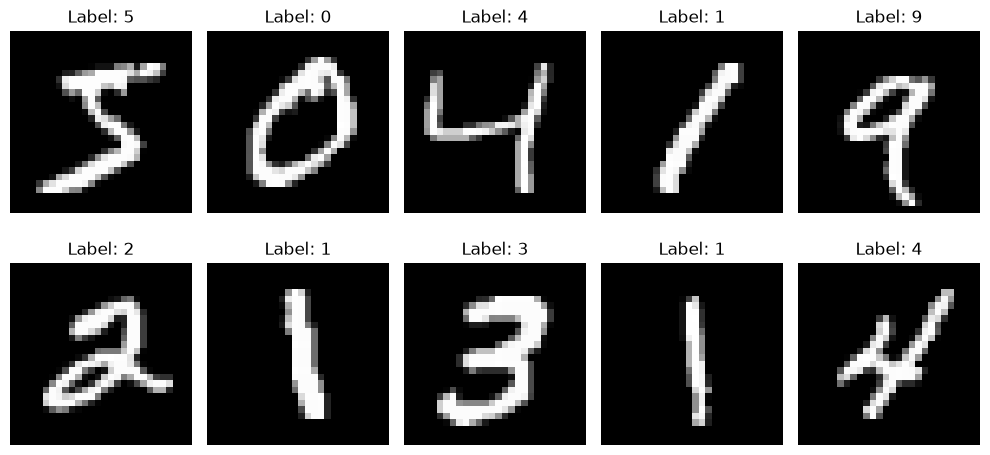

c:\Users\GUE\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9227 - loss: 0.2665 - val_accuracy: 0.9616 - val_loss: 0.1324
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9646 - loss: 0.1132 - val_accuracy: 0.9657 - val_loss: 0.1080
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9758 - loss: 0.0773 - val_accuracy: 0.9687 - val_loss: 0.0974
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9817 - loss: 0.0580 - val_accuracy: 0.9705 - val_loss: 0.0967
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9865 - loss: 0.0421 - val_accuracy: 0.9722 - val_loss: 0.1006
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9882 - loss: 0.0358 - val_accuracy: 0.9729 - val_loss: 0.0997
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9898 - loss: 0.0301 - val_accuracy: 0.9747 - val_loss: 0.0978
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9924 - loss: 0.0235 - 

c:\Users\GUE\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - accuracy: 0.9540 - loss: 0.1516 - val_accuracy: 0.9819 - val_loss: 0.0630
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 16s 11ms/step - accuracy: 0.9847 - loss: 0.0478 - val_accuracy: 0.9808 - val_loss: 0.0601
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 25s 14ms/step - accuracy: 0.9901 - loss: 0.0315 - val_accuracy: 0.9887 - val_loss: 0.0403
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 19s 13ms/step - accuracy: 0.9927 - loss: 0.0226 - val_accuracy: 0.9883 - val_loss: 0.0424
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 17s 11ms/step - accuracy: 0.9949 - loss: 0.0166 - val_accuracy: 0.9902 - val_loss: 0.0364
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 17s 12ms/step - accuracy: 0.9958 - loss: 0.0134 - val_accuracy: 0.9912 - val_loss: 0.0352
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 19s 13ms/step - accuracy: 0.9967 - loss: 0.0100 - val_accuracy: 0.9894 - val_loss: 0.0462
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 20s 13ms/step - accuracy: 0.9969 -

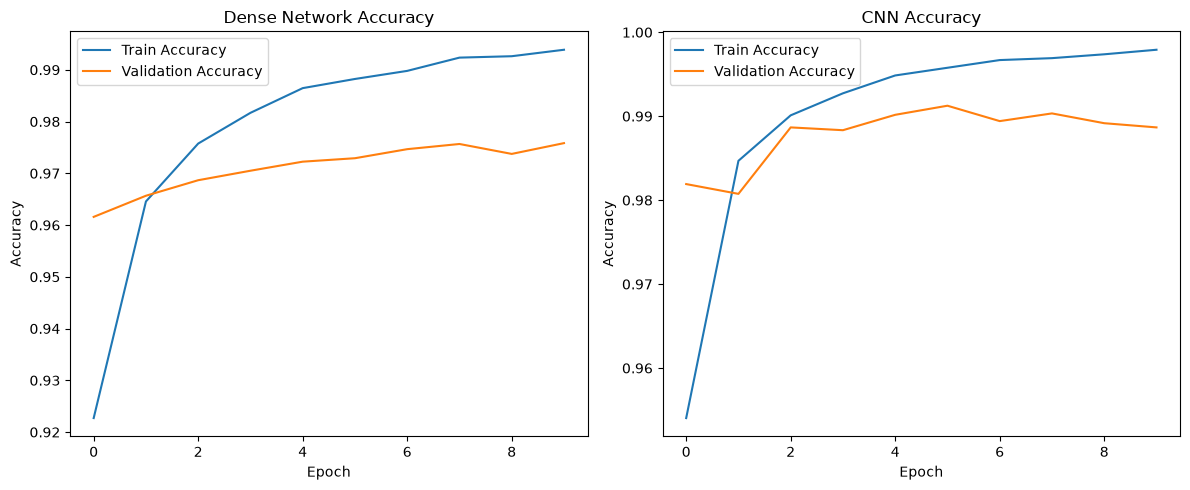

In [3]:
# ============================================================
# DAILY CHALLENGE: CLASSIFYING HANDWRITTEN DIGITS WITH CNNs
# ============================================================

# ------------------------------------------------------------
# 1. IMPORT LIBRARIES
# ------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Dense,
    Flatten,
    Conv2D,
    MaxPooling2D
)
from tensorflow.keras.utils import to_categorical

# ------------------------------------------------------------
# 2. LOAD MNIST DATASET
# ------------------------------------------------------------
(X_train, y_train), (X_test, y_test) = mnist.load_data()

print("Training images shape :", X_train.shape)
print("Training labels shape :", y_train.shape)

print("Testing images shape :", X_test.shape)
print("Testing labels shape :", y_test.shape)

# ------------------------------------------------------------
# 3. VISUALIZE SOME DIGITS
# ------------------------------------------------------------
plt.figure(figsize=(10, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i], cmap="gray")
    plt.title(f"Label: {y_train[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

# ============================================================
# PART 1 : FULLY CONNECTED NEURAL NETWORK
# ============================================================

# ------------------------------------------------------------
# 4. PREPROCESS DATA FOR DENSE NETWORK
# ------------------------------------------------------------

# Flatten images (28x28 -> 784)
X_train_dense = X_train.reshape(-1, 784)
X_test_dense = X_test.reshape(-1, 784)

# Normalize pixels
X_train_dense = X_train_dense / 255.0
X_test_dense = X_test_dense / 255.0

# One-hot encoding labels
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

# ------------------------------------------------------------
# 5. BUILD FULLY CONNECTED MODEL
# ------------------------------------------------------------
dense_model = Sequential([

    Dense(
        128,
        activation="relu",
        input_shape=(784,)
    ),

    Dense(
        64,
        activation="relu"
    ),

    Dense(
        10,
        activation="softmax"
    )
])

# ------------------------------------------------------------
# 6. COMPILE MODEL
# ------------------------------------------------------------
dense_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# ------------------------------------------------------------
# 7. TRAIN MODEL
# ------------------------------------------------------------
history_dense = dense_model.fit(
    X_train_dense,
    y_train_cat,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

# ------------------------------------------------------------
# 8. EVALUATE MODEL
# ------------------------------------------------------------
dense_loss, dense_acc = dense_model.evaluate(
    X_test_dense,
    y_test_cat,
    verbose=0
)

print("\n==============================")
print("FULLY CONNECTED NETWORK")
print("==============================")
print("Test Loss :", dense_loss)
print("Test Accuracy :", dense_acc)

# ============================================================
# PART 2 : CONVOLUTIONAL NEURAL NETWORK
# ============================================================

# ------------------------------------------------------------
# 9. PREPROCESS DATA FOR CNN
# ------------------------------------------------------------

# Reshape images
X_train_cnn = X_train.reshape(-1, 28, 28, 1)
X_test_cnn = X_test.reshape(-1, 28, 28, 1)

# Normalize pixels
X_train_cnn = X_train_cnn / 255.0
X_test_cnn = X_test_cnn / 255.0

# ------------------------------------------------------------
# 10. BUILD CNN MODEL
# ------------------------------------------------------------
cnn_model = Sequential([

    Conv2D(
        32,
        (3, 3),
        activation="relu",
        input_shape=(28, 28, 1)
    ),

    MaxPooling2D((2, 2)),

    Conv2D(
        64,
        (3, 3),
        activation="relu"
    ),

    MaxPooling2D((2, 2)),

    Flatten(),

    Dense(
        128,
        activation="relu"
    ),

    Dense(
        10,
        activation="softmax"
    )
])

# ------------------------------------------------------------
# 11. COMPILE CNN
# ------------------------------------------------------------
cnn_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# ------------------------------------------------------------
# 12. TRAIN CNN
# ------------------------------------------------------------
history_cnn = cnn_model.fit(
    X_train_cnn,
    y_train_cat,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

# ------------------------------------------------------------
# 13. EVALUATE CNN
# ------------------------------------------------------------
cnn_loss, cnn_acc = cnn_model.evaluate(
    X_test_cnn,
    y_test_cat,
    verbose=0
)

print("\n==============================")
print("CONVOLUTIONAL NEURAL NETWORK")
print("==============================")
print("Test Loss :", cnn_loss)
print("Test Accuracy :", cnn_acc)

# ------------------------------------------------------------
# 14. COMPARE PERFORMANCE
# ------------------------------------------------------------
print("\n==============================")
print("MODEL COMPARISON")
print("==============================")

print(f"Fully Connected Accuracy : {dense_acc:.4f}")
print(f"CNN Accuracy             : {cnn_acc:.4f}")

# ------------------------------------------------------------
# 15. PLOT TRAINING CURVES
# ------------------------------------------------------------
plt.figure(figsize=(12,5))

# Dense Model
plt.subplot(1,2,1)

plt.plot(
    history_dense.history["accuracy"],
    label="Train Accuracy"
)

plt.plot(
    history_dense.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("Dense Network Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

# CNN Model
plt.subplot(1,2,2)

plt.plot(
    history_cnn.history["accuracy"],
    label="Train Accuracy"
)

plt.plot(
    history_cnn.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("CNN Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()